## Домашка 1
#### *«Великаны — как луковицы. Лук многослоен! Я тоже! Слой за слоем. Ты усёк? Мы многослойные!» — Шрек*

Эта домашка про декомпозицию и срезы. За неё можно получить максимум 6 баллов. 

**Дедлайны**  
Мягкий дедлайн: 20.09.2026 23:59 по МСК.   
Жесткий дедлайн: 27.09.2026 23:59 по МСК.  

Штраф за сдачу после мягкого дедлайна: –20% от набранного балла.   
После жесткого дедлайна работы не принимаются.   

**Правила сдачи**   
Задание выполняется самостоятельно, списывания не допускаются. При обнаружении одинаковых работ балл за задание анулируется у всех студентов, вне зависимости от того, кто у кого списал.    

**Использование ИИ**
- Использование генеративных моделей для написания кода допустимо при следующих условиях: сгенерированный фрагмент прочитан, адаптирован под условие задачи и данные, вы способны объяснить каждую его строку. Решение, полученное путем передачи модели формулировки задания целиком и прямого копирования ответа в ячейку ноутбука без содержательной переработки, оценивается в 0 баллов за это задание.
- Ответы на текстовые вопросы (описание поведения графика, интерпретация метрики, формулировка гипотез и т.п.) должны быть написаны вами самостоятельно в markdown-ячейках. Использование генеративных моделей для ответа на текстовые вопросы приводит к аннулированию всей работы, а не отдельного задания: интерпретация результатов — главный проверяемый в курсе навык, передача ее ИИ лишает нас возможности оценить, насколько хорошо вы усвоили материал.
- Если генеративная модель использовалась при решении, в конце ноутбука в отдельной markdown-ячейке укажите: номера заданий, при работе над которыми она применялась, использованную модель (с версией) и текст промтов. При обоснованном подозрении на использование ИИ, не отраженное в этом разделе, работа аннулируется целиком независимо от того, к какой части заданий относится подозрение.

#### **Как сдать домашку?**
1. Создайте закрытый репозиторий в личном гитхаб аккаунте для нашего предмета. 
2. Пригласите в него своего ассистента — распределение по ассистентам и их гитхаб юзернеймы находятся в ведомости на листочке нашей дисциплины. Это можно сделать в настройках через раздел Collaborators and teams, уровень доступа ассистента должен быть Write.
3. Скачайте этот ноутбук и решите задания (локально или в Google Colab).
4. В репозитории предмета создайте ветку с номером ДЗ (например hw_1). В эту ветку запушьте .ipynb-файл с решением. Создайте pull request и добавьте в него ассистента как Reviewer. В этот же PR можете пушить сколько угодно изменений, будем смотреть на последнюю версию до наступления дедлайна.
5. Ссылку на PR продублируйте в форме сдачи (форма будет доступна на LMS Karpov Courses и в Телеграм-канале курса).

Пункты 1-2 проделываются один раз. Если вы прошли эти шаги при сдаче других домашек, повторять их не нужно, начинайте сразу с пункта 3. 

**Внимание**: Если вы работаете в Google Colab, также скачивайте .ipynb файл и публикуйте его в репозитории. Ссылки на Colab к сдаче не принимаются.

Все датасеты, с которыми предлагается работать в домашних заданиях, взяты из открытых источников или сгенерированы. Любые паттерны, найденные вне заданной канвы решения, являются случайными и не несут в себе смысла или инсайта.

[Данные](https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/hw_1_data.zip)

In [3]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

### Case Study. Что-то пошло не так в маркетплейсе 🛒

**Легенда**  
Вы работаете продуктовым аналитиком в маркетплейсе. Ваша команда отвечает за функционал корзины — точки входа, дизайн и функционал самой корзины, путь пользователя с момента добавления товара в корзину и до оформления покупки. 

Компания — стартап без системы автоматического мониторинга. Поэтому последние 14 дней, пока вы были в отпуске, никто не следил за метриками корзины. 

Вы отлично отдохнули и в первый же день после каникул рвётесь в бой. Наливаете чашку кофе, открываете ноутбук и проверяете, что творилось в ваше отсутствие.

In [7]:
df = pd.read_parquet('hw_1_marketplace_data.parquet')

In [3]:
df.head()

,user_id,session_id,event_ts,platform,app_version,region,channel,category,event,product_id,price,quantity
0,30,1094418511,2025-04-01 19:49:57,Desktop,web,siberia,ads_search,None,search,NaN,NaN,NaN
1,30,1094418511,2025-04-01 20:02:23,Desktop,web,siberia,ads_search,electronics,view_item,123443.0,NaN,NaN
2,30,1094418511,2025-04-01 20:22:53,Desktop,web,siberia,ads_search,fashion,view_item,162950.0,NaN,NaN
3,30,1094418511,2025-04-01 20:40:57,Desktop,web,siberia,ads_search,home,view_item,199979.0,NaN,NaN
4,30,1094418511,2025-04-01 20:41:07,Desktop,web,siberia,ads_search,home,add_to_cart,199979.0,NaN,NaN


Описание данных

- user_id — уникальный идентификатор пользователя
- session_id — уникальный идентификатор сессии
- event_ts — таймстемп событий
- platform — платформа, с которой пришло событие
- app_version — версия приложения (существует только для iOS и Android, для остальных платформ приходят значения-заглушки)
- region — регион пользователя
- channel — канал, с которого пришел пользователь
- category — категория товаров, которой принадлежит ивент
- event — событие, совершенное пользователем
- product_id — идентификатор товара для событий над товарами
- price — цена товара, ивент приходит только для события покупки
- quantity — количество товаров, ивент приходит только для события покупки

#### **1. Детекция проблемы — 1 балл**

1) Посчитайте подневные конверсии: из просмотра в покупку, из просмотра в добавление в корзину, из добавления в корзину — в покупку.
2) Визуализируйте полученную динамику. 
3) Опишите, что вы видите на графике: когда и в каких метриках началось падение? есть ли устойчивый тренд?

*К подсчёту конверсий можно подойти разными способами — считать их по событиям, сессиям или уникальным юзерам. В нашей задаче будем считать по сессиям.*

In [25]:
def get_line_plot(df, x, y, title, annotate=False):
    fig, ax1 = plt.subplots(figsize=(12,6))
    
    if len(y) == 2:
        ax1.plot(df[x], df[y[0]], label=y[0], color='blue')
        ax1.set_ylabel(y[0])

        plt.xticks(rotation=45)

        if annotate:
            for i, val in enumerate(df[y[0]]):
                ax1.text(df[x].iloc[i], val, f'{val:.2f}', fontsize=9)

        ax2 = ax1.twinx()
        ax2.plot(df[x], df[y[1]], label=y[1], color='green')
        ax2.set_ylabel(f'{y[1]}')
        ax2.tick_params(axis='y')

        if annotate:
            for i, val in enumerate(df[y[1]]):
                ax2.text(df[x].iloc[i], val, f'{val:.2f}', fontsize=9)

        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines + lines2, labels + labels2,
                   loc='center left', bbox_to_anchor=(1.05, 0.8))

        ax1.grid(True, which='both')
        fig.suptitle(title)
        fig.tight_layout()
        
        return plt.show()

    else:
        for col in y:
            plt.plot(df[x], df[col], label=col, color='blue')

            if annotate:
                for i, val in enumerate(df[col]):
                    plt.text(df[x].iloc[i], val, f'{val:.2f}', fontsize=9)

        plt.title(title)
        plt.xlabel('Date')
        plt.ylabel('Metric Value')
        plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.8))
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()

    return plt.show()

In [110]:
def get_several_lines_plot(df, x, y_list, title):
    plt.figure(figsize=(12,6))
    colors = ['green', 'blue', 'orange', 'pink', 'violet']
    
    for i, col in enumerate(y_list):
        if x == 'date':
            x_axis = df[x]
        else:
            x_axis = df[x].astype(str)

        y_axis = df[col]
        plt.plot(x_axis, y_axis, label=col, color=colors[i])

        for xi, yi in zip(x_axis, y_axis):
            plt.text(xi, yi, f'{yi:.2f}', fontsize=9, ha='center', va='bottom')

    plt.title(title)
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.ylabel('Metric Value')
    
    plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.9))
    
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [42]:
# df.groupby('session_id')['event', ''].value_counts()
df['date'] = df['event_ts'].dt.date
df

,user_id,session_id,event_ts,platform,app_version,region,channel,category,event,product_id,price,quantity,date
0,30,1094418511,2025-04-01 19:49:57,Desktop,web,siberia,ads_search,None,search,NaN,NaN,NaN,2025-04-01
1,30,1094418511,2025-04-01 20:02:23,Desktop,web,siberia,ads_search,electronics,view_item,123443.0,NaN,NaN,2025-04-01
2,30,1094418511,2025-04-01 20:22:53,Desktop,web,siberia,ads_search,fashion,view_item,162950.0,NaN,NaN,2025-04-01
3,30,1094418511,2025-04-01 20:40:57,Desktop,web,siberia,ads_search,home,view_item,199979.0,NaN,NaN,2025-04-01
4,30,1094418511,2025-04-01 20:41:07,Desktop,web,siberia,ads_search,home,add_to_cart,199979.0,NaN,NaN,2025-04-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
266826,24972,9318129430,2025-04-30 19:15:17,Desktop,web,volga,ads_search,electronics,view_item,192321.0,NaN,NaN,2025-04-30
266827,24972,9318129430,2025-04-30 19:15:27,Desktop,web,volga,ads_search,electronics,add_to_cart,192321.0,NaN,NaN,2025-04-30
266828,24972,9318129430,2025-04-30 18:58:12,Desktop,web,volga,ads_search,home,view_item,157069.0,NaN,NaN,2025-04-30
266829,24972,9318129430,2025-04-30 19:06:39,Desktop,web,volga,ads_search,beauty,view_item,164901.0,NaN,NaN,2025-04-30


In [62]:
df[df['event'] == 'view_item']

,user_id,session_id,event_ts,platform,app_version,region,channel,category,event,product_id,price,quantity,date
1,30,1094418511,2025-04-01 20:02:23,Desktop,web,siberia,ads_search,electronics,view_item,123443.0,NaN,NaN,2025-04-01
2,30,1094418511,2025-04-01 20:22:53,Desktop,web,siberia,ads_search,fashion,view_item,162950.0,NaN,NaN,2025-04-01
3,30,1094418511,2025-04-01 20:40:57,Desktop,web,siberia,ads_search,home,view_item,199979.0,NaN,NaN,2025-04-01
5,50,4844708827,2025-04-01 22:48:21,Mobile,web,urals,organic,fashion,view_item,162222.0,NaN,NaN,2025-04-01
7,50,4844708827,2025-04-01 22:02:48,Mobile,web,urals,organic,beauty,view_item,106520.0,NaN,NaN,2025-04-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
266824,24960,9412331344,2025-04-30 08:40:27,Android,13.0.0,urals,organic,beauty,view_item,146859.0,NaN,NaN,2025-04-30
266825,24964,6840900050,2025-04-30 19:34:28,Mobile,web,central,organic,electronics,view_item,117871.0,NaN,NaN,2025-04-30
266826,24972,9318129430,2025-04-30 19:15:17,Desktop,web,volga,ads_search,electronics,view_item,192321.0,NaN,NaN,2025-04-30
266828,24972,9318129430,2025-04-30 18:58:12,Desktop,web,volga,ads_search,home,view_item,157069.0,NaN,NaN,2025-04-30


In [88]:
view_sessions = df[df['event'] == 'view_item'].groupby('date')['session_id'].nunique()
view_sessions.values

array([1949, 2092, 2124, 2291, 3187, 2813, 1923, 1892, 2056, 2158, 2448,
       3244, 2804, 1896, 1955, 1992, 2189, 2473, 3220, 2908, 1958, 2035,
       2102, 2078, 2354, 3287, 2794, 1859, 1911, 2113])

In [86]:
add_to_cart_sessions = df[df['event'] == 'add_to_cart'].groupby('date')['session_id'].nunique()
add_to_cart_sessions.values

array([ 633,  677,  668,  764, 1049,  942,  647,  606,  706,  650,  819,
       1031,  929,  642,  605,  690,  717,  984, 1380, 1235,  889,  941,
        916,  910, 1036, 1461, 1270,  817,  891,  920])

In [84]:
purchase_sessions = df[df['event'] == 'purchase'].groupby('date')['session_id'].nunique()
purchase_sessions.values

array([209, 208, 201, 215, 337, 279, 202, 183, 216, 180, 273, 319, 304,
       201, 188, 231, 207, 263, 363, 286, 195, 197, 191, 207, 233, 341,
       293, 183, 216, 208])

In [106]:
conversions = pd.DataFrame({
'index': view_sessions.index,
'cr_add_viev': add_to_cart_sessions.values/view_sessions.values,
'cr_purch_view': purchase_sessions.values/view_sessions.values,
'cr_purch_add': purchase_sessions.values/add_to_cart_sessions.values})
conversions

,index,cr_add_viev,cr_purch_view,cr_purch_add
0,2025-04-01,0.324782,0.107234,0.330174
1,2025-04-02,0.323614,0.099426,0.307238
2,2025-04-03,0.314501,0.094633,0.300898
3,2025-04-04,0.333479,0.093845,0.281414
4,2025-04-05,0.329150,0.105742,0.321258
5,2025-04-06,0.334874,0.099182,0.296178
6,2025-04-07,0.336453,0.105044,0.312210
7,2025-04-08,0.320296,0.096723,0.301980
8,2025-04-09,0.343385,0.105058,0.305949
9,2025-04-10,0.301205,0.083411,0.276923


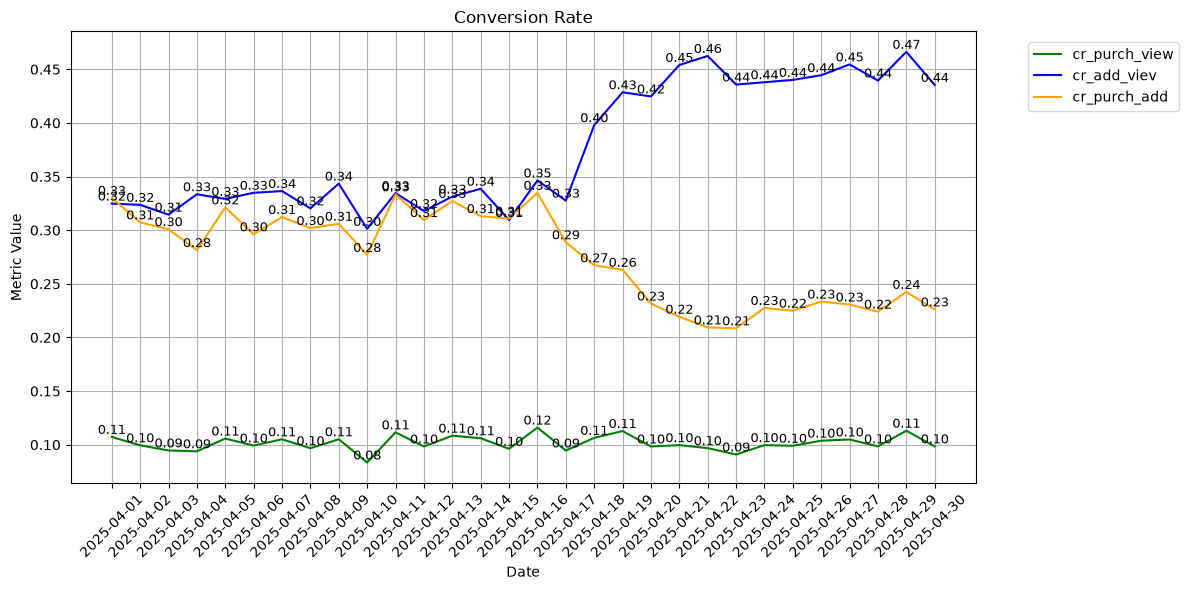

In [114]:
get_several_lines_plot(conversions, 'index', ['cr_purch_view', 'cr_add_viev', 'cr_purch_add'], 'Conversion Rate')

#### Получили серьёзное падение из добавления в корзину до покупки, но повышение количество добавлений из просмотра 
### Итоговая конверсия из просмотра в покупку не упала, что является хорошим знаком. 

#### **2. Проверка абсолютных и средних значений — 1 балл**

1) Постройте графики дневной динамики абсолютных значений, из которых рассчитаны конверсии выше.
2) Рассчитайте и визуализируйте среднее число событий (именно событий, не сессий), из которых рассчитаны конверсии, на пользователя. 
3) На каком этапе воронки появилась проблема?

In [127]:
abs_avg = pd.DataFrame({
'index': view_sessions.index, 
'to_cart': add_to_cart_sessions.values,
'purchase': purchase_sessions.values,
'view': view_sessions.values
})

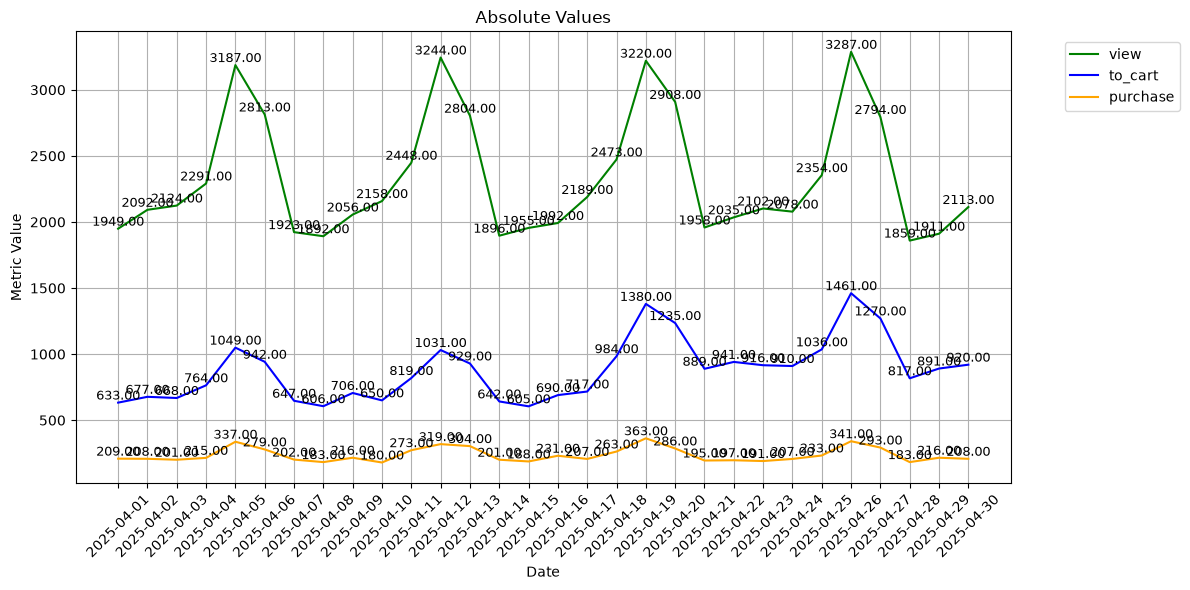

In [129]:
get_several_lines_plot(abs_avg, 'index', ['view', 'to_cart', 'purchase'], 'Absolute Values')

In [179]:
abs_avg_per_session = pd.DataFrame({
'index': view_sessions.index, 
'to_cart': df[df['event'] == 'add_to_cart'].groupby(['date'])['session_id'].size().values / df[df['event'] == 'add_to_cart'].groupby(['date'])['user_id'].nunique().values,
'purchase': df[df['event'] == 'purchase'].groupby(['date'])['session_id'].size().values / df[df['event'] == 'purchase'].groupby(['date'])['user_id'].nunique().values,
'view': df[df['event'] == 'view_item'].groupby(['date'])['session_id'].size().values / df[df['event'] == 'view_item'].groupby(['date'])['user_id'].nunique().values
})
abs_avg_per_session

,index,to_cart,purchase,view
0,2025-04-01,1.285714,1.068627,3.279070
1,2025-04-02,1.304274,1.070352,3.338398
2,2025-04-03,1.294509,1.067010,3.334466
3,2025-04-04,1.297904,1.096618,3.346734
4,2025-04-05,1.348066,1.080247,3.632693
5,2025-04-06,1.329161,1.063910,3.654342
6,2025-04-07,1.298791,1.029851,3.352679
7,2025-04-08,1.269871,1.038889,3.353788
8,2025-04-09,1.302100,1.048077,3.318560
9,2025-04-10,1.254701,1.039548,3.282869


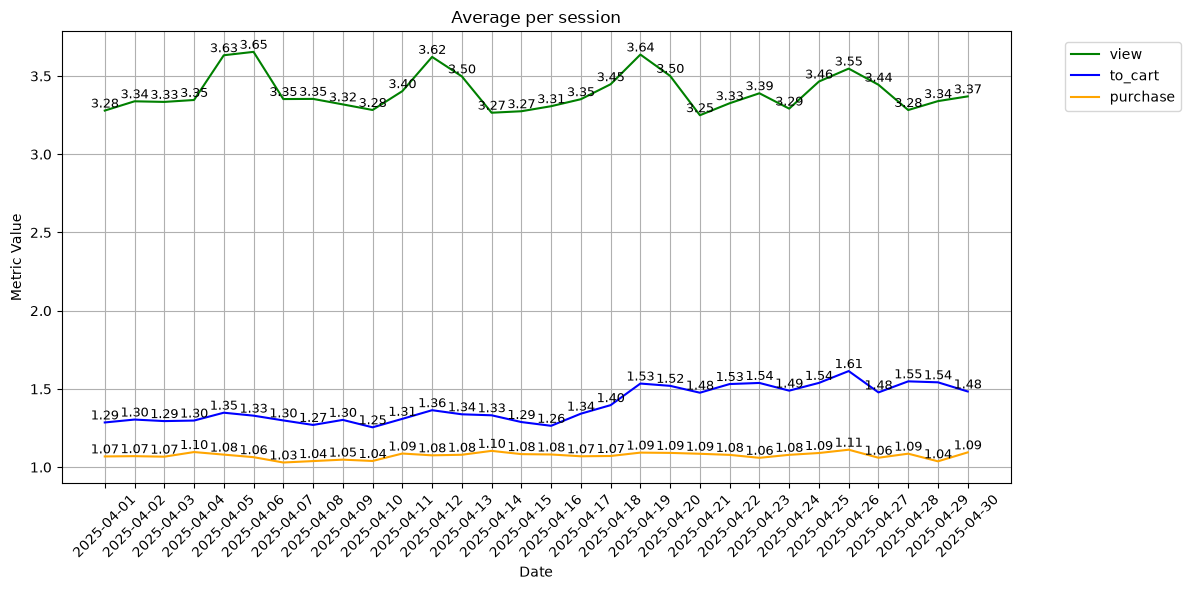

In [180]:
get_several_lines_plot(abs_avg_per_session, 'index', ['view', 'to_cart', 'purchase'], 'Average per session')

#### Глобально с просмотрами на одного пользователя ничего не изменилось
### Что-то произошло только с добавлением в корзину (скорее всего баг) или редизайн карточек (стали более вкусными), но покупательная способность клиентов осталась на прошлом уровне 

#### **3. Базовые срезы — 1 балл**
1. Постройте динамику события, среднее значение которого подскочило, в разрезе:
- платформ,
- регионов,
- источников трафика,
- категорий товаров.

2. Есть ли выделяющийся срез?

*В этом пункте в качестве события продолжаем смотреть метрику среднего на пользователя*

In [275]:
platform = df[df['event'] == 'add_to_cart'].groupby(['date', 'platform']).size() / df[df['event'] == 'add_to_cart'].groupby(['date', 'platform'])['user_id'].nunique()
platform = platform.unstack().reset_index()

In [277]:
platform

platform,date,Android,Desktop,Mobile,iOS
0,2025-04-01,1.301587,1.284091,1.261905,1.254098
1,2025-04-02,1.326599,1.271186,1.363636,1.270073
2,2025-04-03,1.284345,1.254717,1.281250,1.346667
3,2025-04-04,1.303951,1.266129,1.244444,1.323529
4,2025-04-05,1.347458,1.338542,1.392857,1.345946
5,2025-04-06,1.345411,1.298013,1.274510,1.333333
6,2025-04-07,1.305556,1.290909,1.351351,1.268519
7,2025-04-08,1.264407,1.178947,1.258065,1.358333
8,2025-04-09,1.287425,1.258333,1.512821,1.317460
9,2025-04-10,1.281250,1.234783,1.250000,1.201754


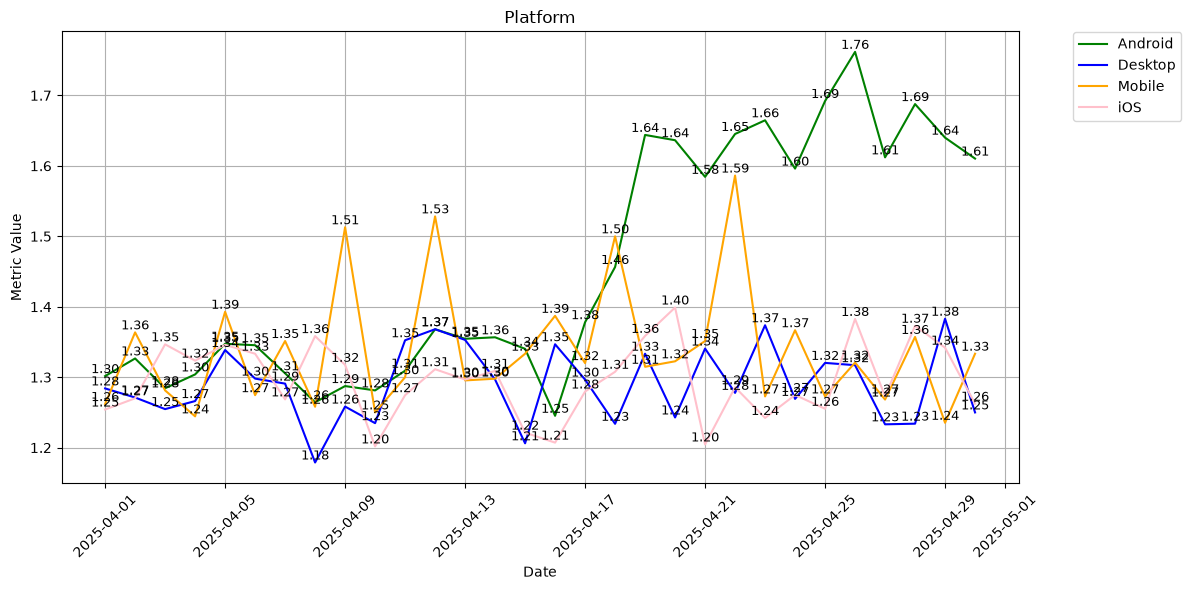

In [279]:
get_several_lines_plot(platform, 'date', ['Android', 'Desktop', 'Mobile', 'iOS'], title = 'Platform')

# plt.plot((df[df['event'] == 'add_to_cart'].groupby(['date', 'platform']).size() / df[df['event'] == 'add_to_cart'].groupby(['date', 'platform'])['user_id'].nunique()).unstack())
# plt.legend()

In [ ]:
Из графика сразу видно, что проблема возника с Andoroid, и, возможно, 

IndexError: list index out of range

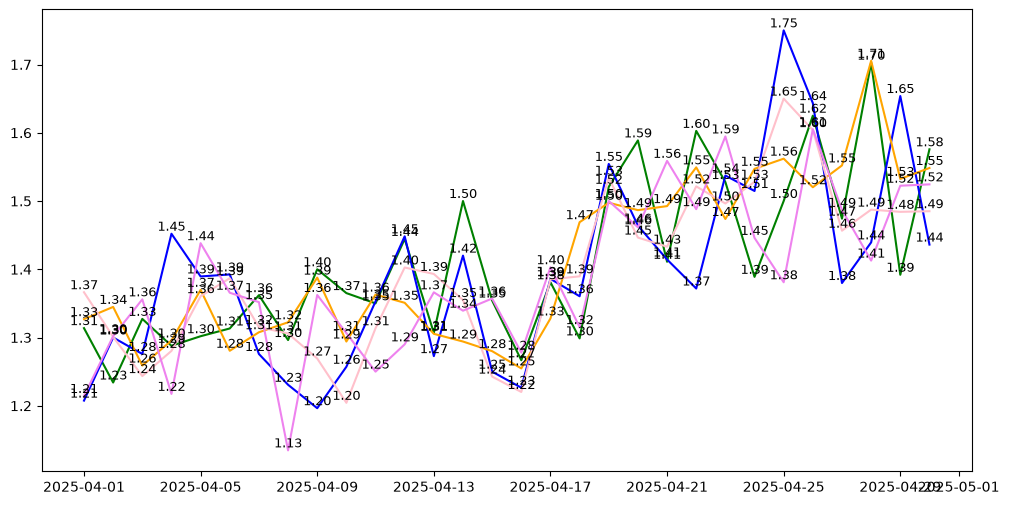

In [294]:
region = df[df['event'] == 'add_to_cart'].groupby(['date', 'region']).size() / df[df['event'] == 'add_to_cart'].groupby(['date', 'region'])['user_id'].nunique()
region = region.unstack().reset_index()
unique_regions = df['region'].unique()
get_several_lines_plot(region, 'date', unique_regions, title = 'Region')

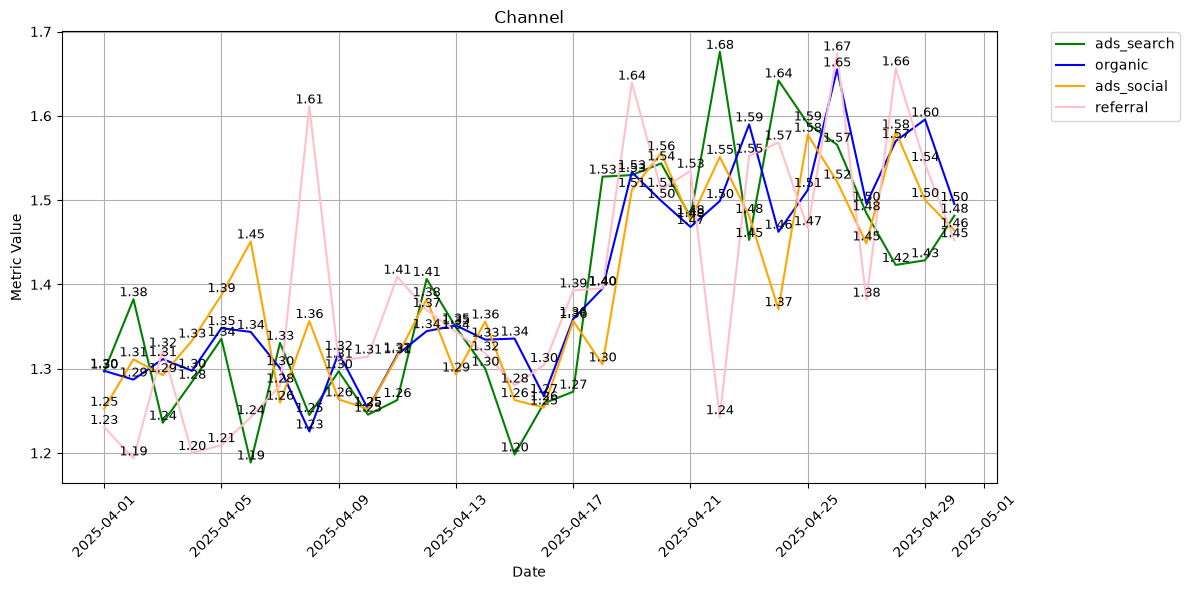

In [298]:
channel = df[df['event'] == 'add_to_cart'].groupby(['date', 'channel']).size() / df[df['event'] == 'add_to_cart'].groupby(['date', 'channel'])['user_id'].nunique()
channel = channel.unstack().reset_index()
unique_channels = df['channel'].unique()
get_several_lines_plot(channel, 'date', unique_channels, title = 'Channel')

In [319]:
category = df[df['event'] == 'add_to_cart'].groupby(['date', 'category']).size() / df[df['event'] == 'add_to_cart'].groupby(['date', 'category'])['user_id'].nunique()
category = category.unstack().reset_index()
unique_category = df['category'].unique() 
get_several_lines_plot(category, 'date', unique_category, title = 'Category')

KeyError: 'None'

<Figure size 1200x600 with 0 Axes>

In [309]:
unique_category

array(['None', 'electronics', 'fashion', 'home', 'beauty', 'garden'],
      dtype=object)

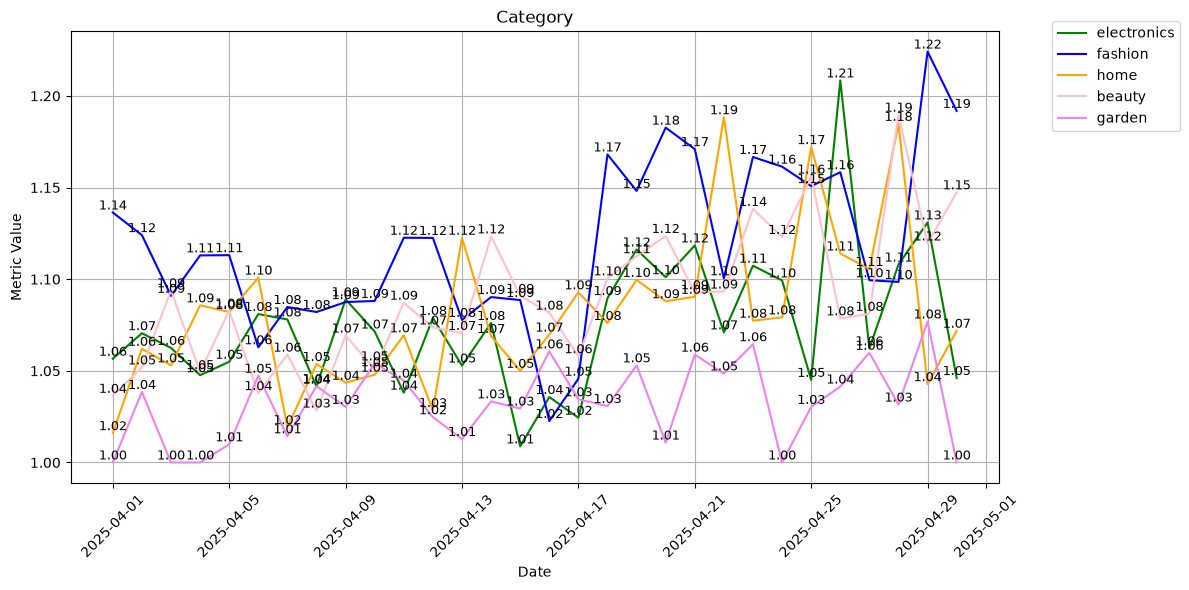

In [324]:
unique_category = ['electronics', 'fashion', 'home', 'beauty', 'garden']
category = df[df['event'] == 'add_to_cart'].groupby(['date', 'category']).size() / df[df['event'] == 'add_to_cart'].groupby(['date', 'category'])['user_id'].nunique()
category = category.unstack().reset_index()
get_several_lines_plot(category, 'date', unique_category, title = 'Category')

#### **4. Детальные срезы — 1 балл**
1. Постройте динамику события для iOS и Android с разложением по версиям приложения.
2. Помогло ли это локализовать проблему?

*В этом пункте в качестве события продолжаем смотреть метрику среднего на пользователя*

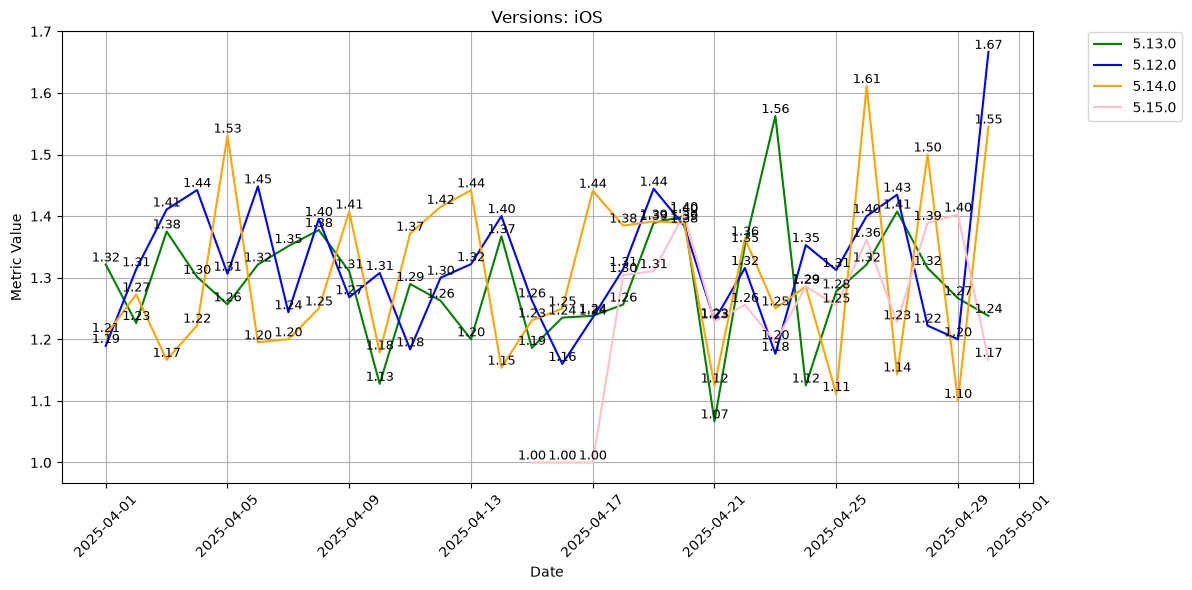

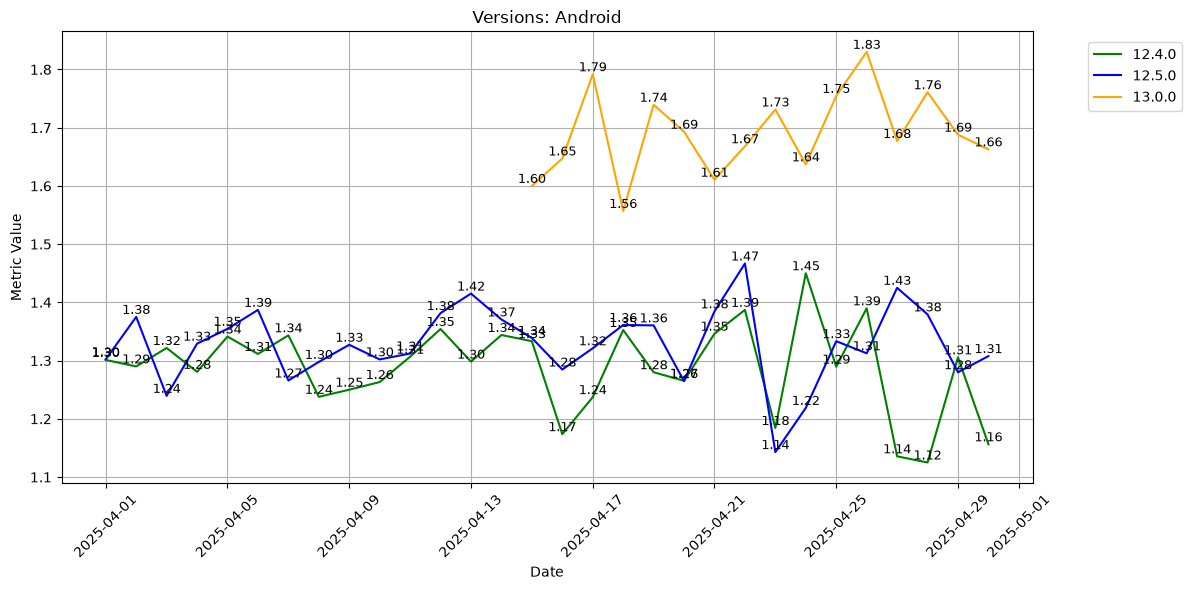

In [361]:
for platform in ['iOS', 'Android']:
    body = df[(df['event'] == 'add_to_cart') & (df['platform'] == platform)].groupby(['date', 'app_version'])
    app_version = body.size() / body['user_id'].nunique()
    app_version = app_version.unstack().reset_index()
    app_version_unique = df[(df['event'] == 'add_to_cart') & (df['platform'] == platform)].app_version.unique()
    get_several_lines_plot(app_version, 'date', app_version_unique, title = f'Versions: {platform}')


### Видим, что в новой версии на Android произошёл баг с дубликацией, начиная с середины апреля (как только она вышла в релиз) 

#### **5. Поиск причин — 1 балл**
1. Для проблемной платформы постройте динамику ВСЕХ событий в разрезе версий приложения.
2. Сформулируйте гипотезу, что именно могло пойти не так в новом релизе? Может быть, пользователи стали заменять один функционал другим?

*В этом пункте в качестве событий продолжаем смотреть метрику среднего на пользователя*

### До выполнения задания, предполагаю, что случайно выпилили "избранное", поэтому пользователи начали добавлять желанные товары в корзину

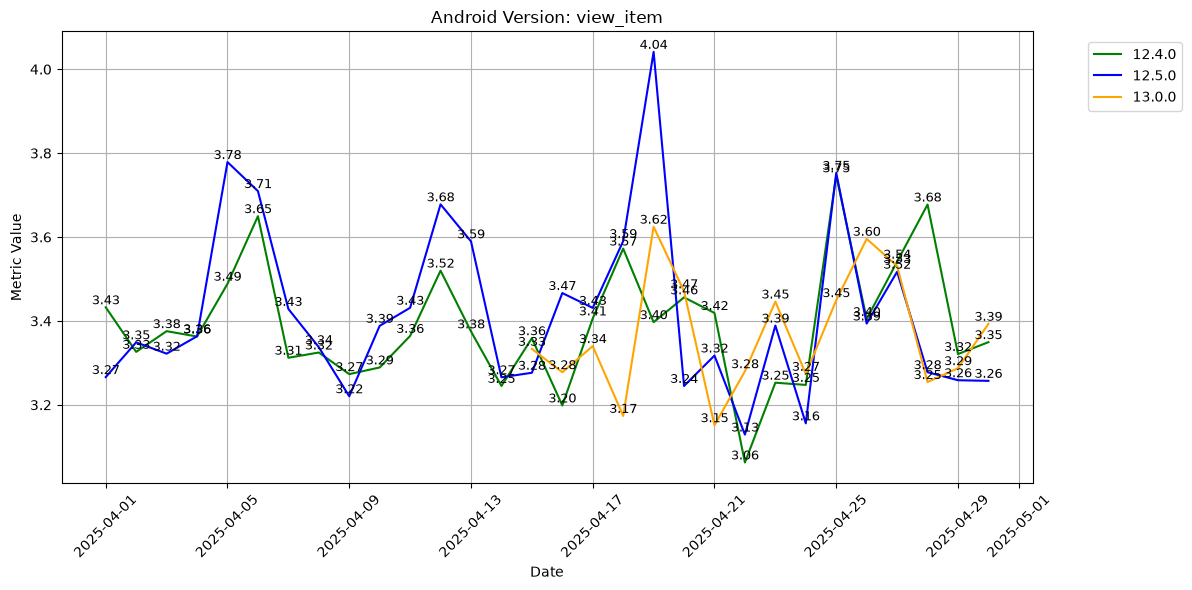

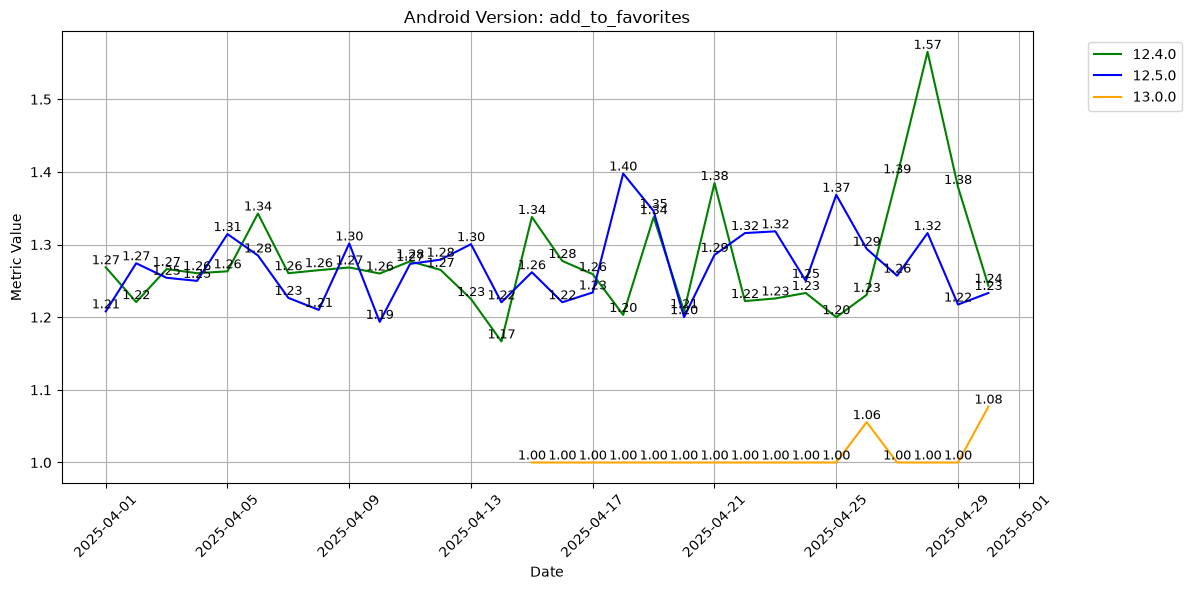

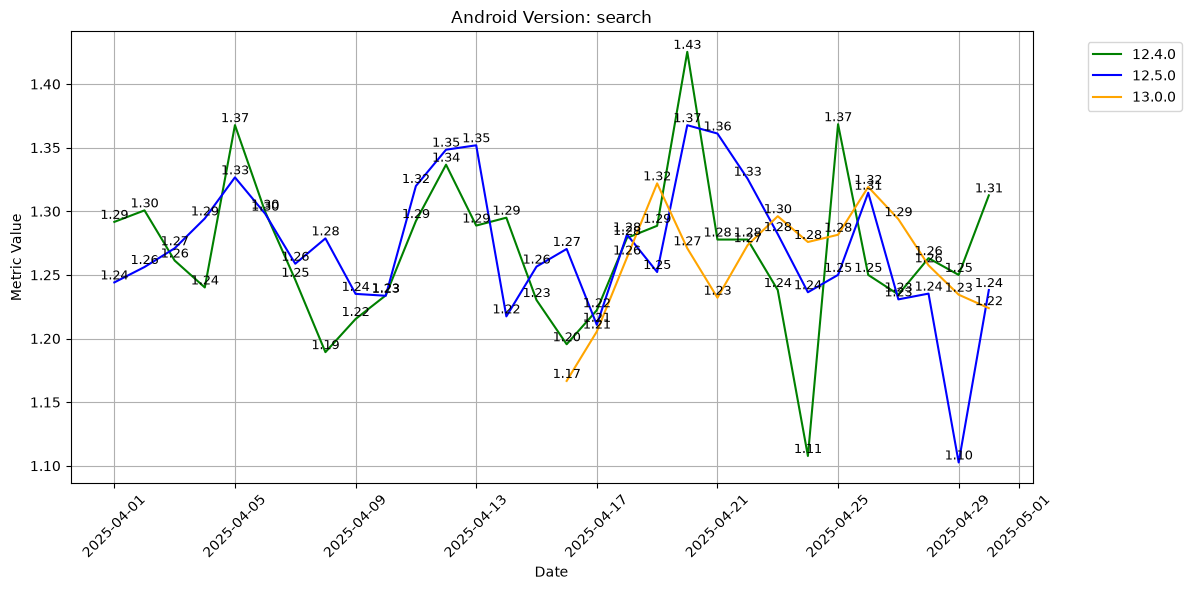

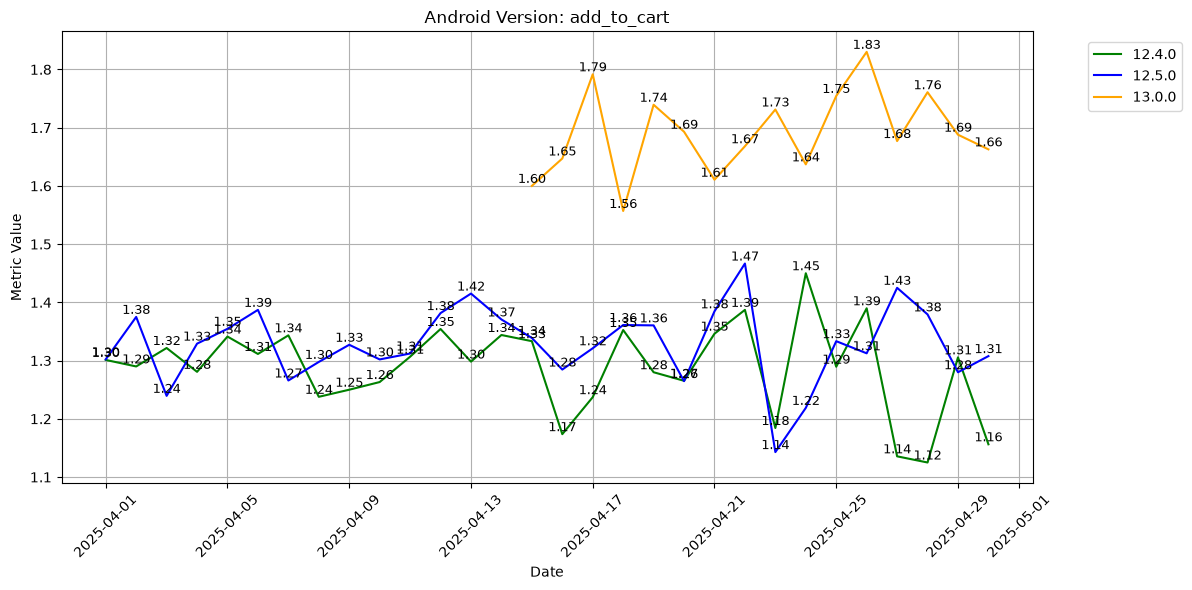

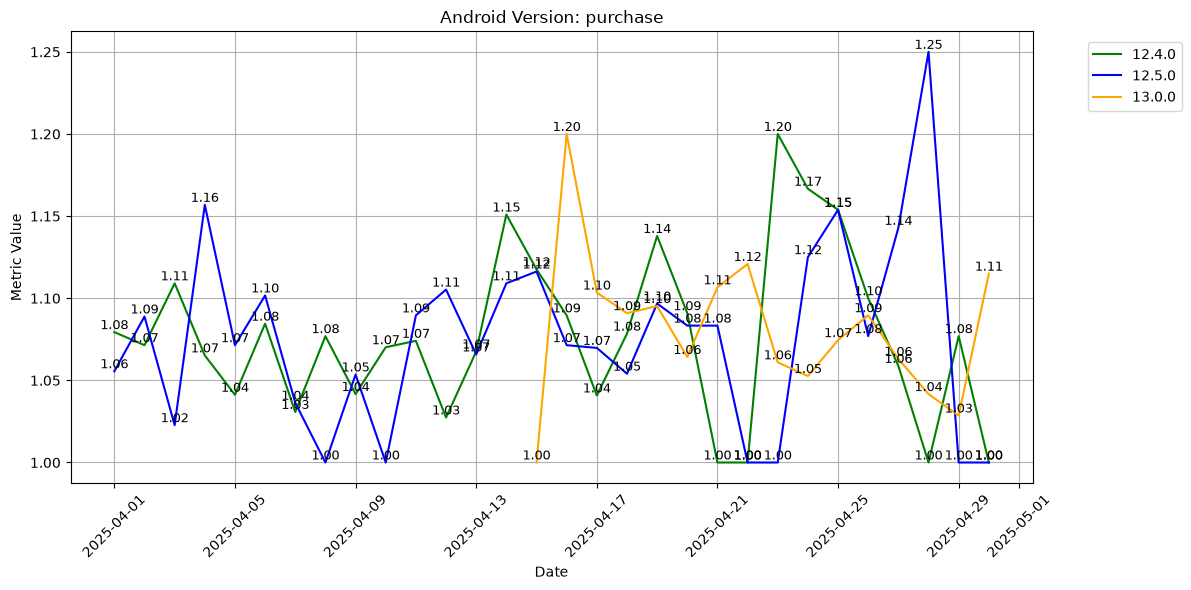

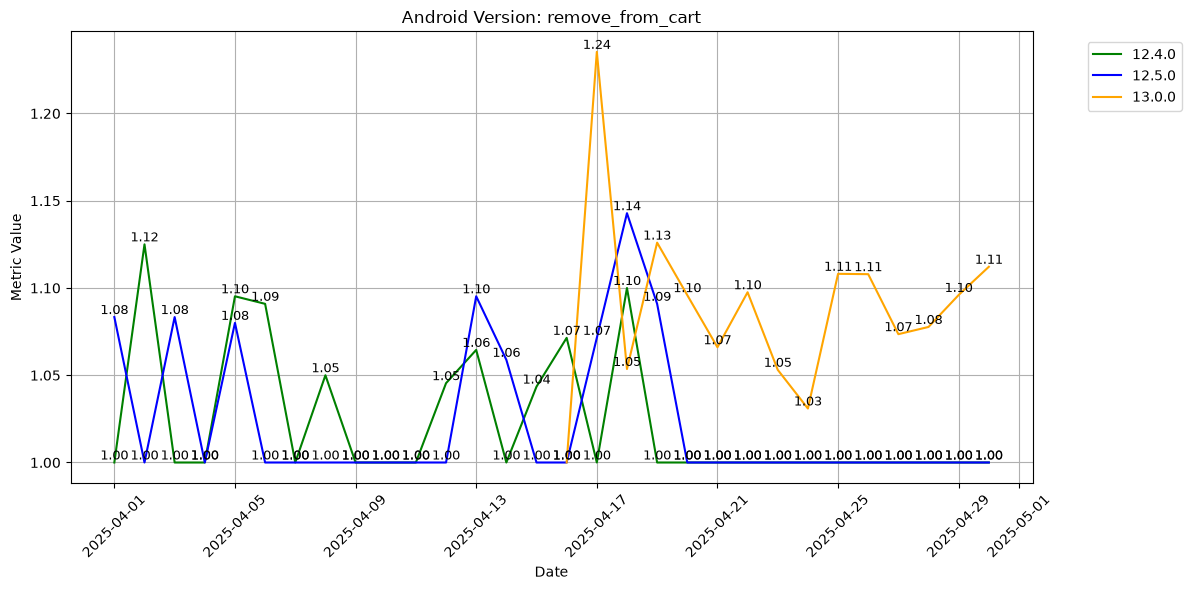

In [392]:
events = df[(df['platform'] == 'Android')].event.unique()
for event in events:
    body = df[(df['platform'] == 'Android') & (df['event'] == event)].groupby(['date', 'app_version'])
    app_version = body.size() / body['user_id'].nunique()
    app_version = app_version.unstack().reset_index()
    get_several_lines_plot(app_version, 'date', app_version_unique, title = f'Android Version: {event}')


#### Да чёт реально умер функционал добавления в избранное в новой версии, поэтому клиенты начали постоянно добавлять и убирать из коризны товары

#### **6. Новости для команды — 1 балл**

На основе проведённого расследования подготовьте сообщение для команды о том, что именно пошло не так.

С середины апреля вырос CV из просмотра в добавление в корзину, а CV из корзины в покупку - упал. 
Глобальная метрика продукта: количество покупок не пострадала (хорошо) 
Конверсия из просмотра в покупку в итоге почти не изменилась, но воронка внутри flow клиента изменилась

Проблема оказалась в последнем релизе на Android - версии 13.0.0 

В версии 13.0.0 практически исчезли события add_to_favorites - с ~4300 событий на версии 12.4.0 и ~3700 на 12.5.0 до 212 на 13.0.0, при сопоставимом числе пользователей. Похоже, в новом релизе сломалась или пропала кнопка «добавить в избранное». Пользователи, которым нужно было отложить товар, стали вместо неё нажимать «в корзину» - отсюда рост add_to_cart без роста покупок, и как следствие просадка конверсии cart - purchase.

Нужно проверить функционал избранного в релизе 13.0.0 - скорее всего это баг в приле или её убрали при редизайне (маловероятно, так как значение != 0)
Сделать краткий фикс и поставить данный мониторинг на ежедневную основу, по срезам платформы-версии, чтобы не терять результаты взаимодействия